# Constant σ changing N

Here we can look at what the graph looks like when we have a constant $\sigma$, and how does $N$ affect these results.

In [271]:
using ITensors, ITensorMPS, Plots
include("../../data/params.jl")
include("../../data/helpers/saving.jl")
include("./get_spectrum.jl")
include("deviation/deviation.jl")

   Resolving package versions...
     Project No packages added to or removed from `~/dev/uni/msciproject/Project.toml`
    Manifest No packages added to or removed from `~/dev/uni/msciproject/Manifest.toml`


find_deviation_idx (generic function with 1 method)

In [272]:
@info "Setting paramters..."
# now want to load in the mps states we want
σ = 0.002
N_vals = 20:20:80
system_params = Dict{String,Any}(
    "J" => -1.0,
    "Δ" => -1.0,
    "μ" => 1.0,
    "NUM_SWEEPS" => 30,
    "MAX_BOND_DIM" => 1000,
    "ACC" => 1e-16 # use a relatively low accuracy
)
acc = system_params["ACC"]

┌ Info: Setting paramters...
└ @ Main /Users/jamesneville-rolfe/dev/uni/msciproject/programs/schmidt_spectra/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_W0sZmlsZQ==.jl:1


1.0e-16

In [273]:
FILENAME = extract_filename_from_system_params(system_params)
CURRENT_DIR = @__DIR__
MPS_FILEPATH = path = joinpath(CURRENT_DIR, "../../data/storage/$(FILENAME).hd5")
@info "Searching filepath '$MPS_FILEPATH'"

┌ Info: Searching filepath '/Users/jamesneville-rolfe/dev/uni/msciproject/programs/schmidt_spectra/../../data/storage/Δ=-1.00e+00_J=-1.00e+00_μ=1.00e+00_MAX_BOND_DIM=1000_NUM_SWEEPS=30_ACC=1.00e-16.hd5'
└ @ Main /Users/jamesneville-rolfe/dev/uni/msciproject/programs/schmidt_spectra/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_W2sZmlsZQ==.jl:4


In [274]:
@info "Creating Schmidt spectra..."
# store schmidt spectra in a map relating to the system size
N_to_SS_map = Dict{Int, Vector{Float64}}()
for N in N_vals
    @info "Starting N=$N"
    run_params = Dict{String, Any}(
        "N" => N,
        "σ" => σ
    )
    matches = nothing
    try
        @info "Finding N=$N, σ=$σ"
        matches = find_runs_by_params(MPS_FILEPATH, run_params; load_psi=true, instance_selection=:all)
    catch e
        @warn "Could not find MPS data for N=$N, σ=$σ"
        matches = []
    end

    if isempty(matches)
        @warn "Could not find data for N=$N, σ=$σ"
        continue end

    num_runs = min(1, length(matches))
    @info "Using latest $num_runs runs for averaging."

    all_spectra = []
    for i in 1:num_runs
        m = matches[i]
        if m.psi === nothing
            @warn "Could not find psi for run $i"
            continue end

        @info "Run $i: Calculating Schmidt Spectra"
        schmidt_spectra = get_squared_sorted_schmidt_spectrum_from_mps(m.psi)
        push!(all_spectra, schmidt_spectra)
    end

    if isempty(all_spectra)
        @warn "No valid spectra for N=$N"
        continue end

    max_len = maximum(length.(all_spectra))

    averaged_spectrum = zeros(max_len)
    for spec in all_spectra
        for (i,val) in enumerate(spec)
            averaged_spectrum[i] += val
        end
    end

    averaged_spectrum ./ length(all_spectra)

    # remove trailing zeros if any
    last_nonzero = findlast(x -> x > 0, averaged_spectrum)
    if last_nonzero !== nothing
        averaged_spectrum = averaged_spectrum[1:last_nonzero]
    end

    @info "Averaged $(length(all_spectra)) spectra for N=$N"

    sum_ss = sum(averaged_spectrum)
    @info " Average Schmidt Spectra sum: Σλ_i^2 = $sum_ss"

    N_to_SS_map[N] = averaged_spectrum
end

┌ Info: Creating Schmidt spectra...
└ @ Main /Users/jamesneville-rolfe/dev/uni/msciproject/programs/schmidt_spectra/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_W3sZmlsZQ==.jl:1
┌ Info: Starting N=20
└ @ Main /Users/jamesneville-rolfe/dev/uni/msciproject/programs/schmidt_spectra/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_W3sZmlsZQ==.jl:5
┌ Info: Finding N=20, σ=0.002
└ @ Main /Users/jamesneville-rolfe/dev/uni/msciproject/programs/schmidt_spectra/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_W3sZmlsZQ==.jl:12
┌ Info: Using latest 1 runs for averaging.
└ @ Main /Users/jamesneville-rolfe/dev/uni/msciproject/programs/schmidt_spectra/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_W3sZmlsZQ==.jl:24
┌ Info: Run 1: Calculating Schmidt Spectra
└ @ Main /Users/jamesneville-rolfe/dev/uni/msciproject/programs/schmidt_spectra/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_W3sZmlsZQ==.jl:33
┌ Info: Averaged 1 spectra for N=20
└ @ Main /Users/jamesneville-rolfe/dev/uni/msciproje

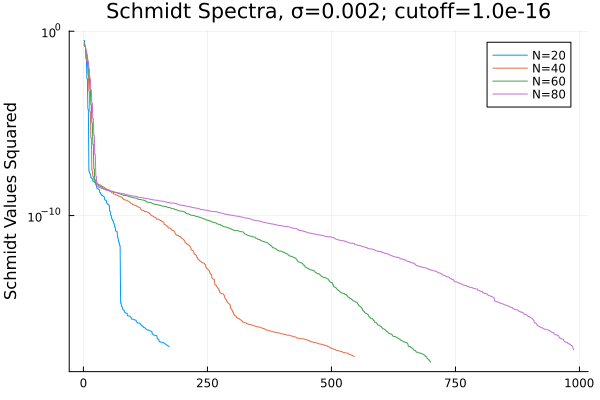

"/Users/jamesneville-rolfe/dev/uni/msciproject/programs/schmidt_spectra/schmidt_spectra_constant_disorder_σ=0.002_acc=1.0e-16.png"

In [275]:
acc = system_params["ACC"]
p = plot(title="Schmidt Spectra, σ=$σ; cutoff=$acc", ylabel="Schmidt Values Squared", legend=:topright,
    yscale=:log,
    # xscale=:log
)

for N in N_vals
    if !haskey(N_to_SS_map, N)
        continue
    end

    spec = N_to_SS_map[N]

    plot!(p, 1:length(spec), spec, label="N=$N")
end

display(p)
savefig(p, joinpath(CURRENT_DIR, "schmidt_spectra_constant_disorder_σ=$(σ)_acc=$acc.png"))

# Deviation Index

We can get the 'deviation index' - e.g. the point at which we transition from the 'head' to the 'tail'.

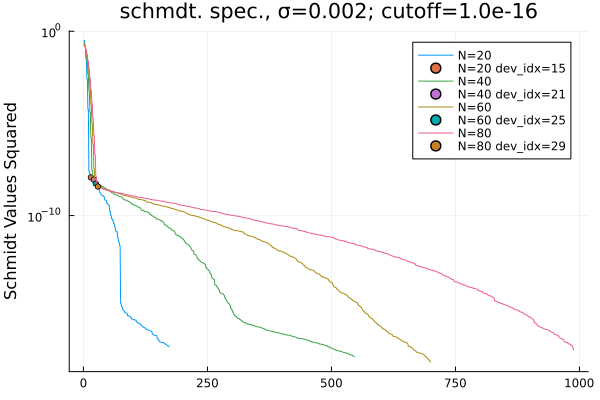

In [276]:
acc = system_params["ACC"]
p = plot(title="schmdt. spec., σ=$σ; cutoff=$acc", ylabel="Schmidt Values Squared", legend=:topright,
    yscale=:log,
    # xscale=:log
)

dev_idxs = Dict{Int, Int}()
for N in N_vals
    if !haskey(N_to_SS_map, N)
        continue
    end

    spec = N_to_SS_map[N]

    # want to find the deviation index using kneedle
    dev_idx = find_deviation_idx(spec)
    dev_idx_val = spec[dev_idx]

    dev_idxs[N] = dev_idx

    plot!(p, 1:length(spec), spec, label="N=$N")
    scatter!(p, [dev_idx], [dev_idx_val], markersize=3, label="N=$N dev_idx=$dev_idx")
end

display(p)
# savefig(p, joinpath(CURRENT_DIR, "schmidt_spectra_constant_disorder_σ=$(σ)_acc=$acc.png"))

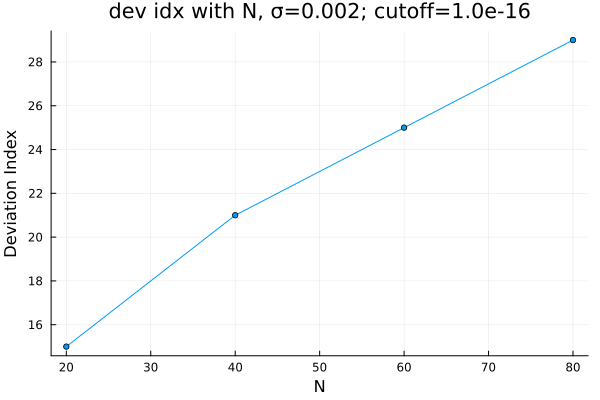

In [277]:
sorted_pairs = sort(collect(dev_idxs), by = x -> x[1])
ns = first.(sorted_pairs)
idxs = last.(sorted_pairs)
p1 = plot(
    ns, idxs,
    title="dev idx with N, σ=$σ; cutoff=$acc",
    ylabel="Deviation Index",
    xlabel="N",
    markersize=3,
    marker=:circle,
    legend=false,
)

display(p1)
# savefig(p1, joinpath(CURRENT_DIR, "dev_idx_vs_size_σ=$(σ)_acc=$acc.png"))

In [278]:
function calculate_sum_of_schmidt_coeffs_around_dev_idx(spec::Vector{Float64}, dev_idx::Int64)::Tuple{Float64, Float64}
    head = spec[1:dev_idx]
    tail = spec[dev_idx+1:end]
    return sum(head), sum(tail)
end

calculate_sum_of_schmidt_coeffs_around_dev_idx (generic function with 1 method)

In [279]:
sorted_pairs = sort(collect(dev_idxs), by = x -> x[1])

for (n, idx) in sorted_pairs
    ss = N_to_SS_map[n]
    head, tail = calculate_sum_of_schmidt_coeffs_around_dev_idx(ss, idx)
    perc = ( tail / (head + tail) ) * 100
    println("N=$n : tail weight $(perc)%")
end

N=20 : tail weight 1.1990644144005852e-5%
N=40 : tail weight 2.0011216016535926e-5%
N=60 : tail weight 2.1408210429951058e-5%
N=80 : tail weight 2.377428279617928e-5%


┌ Info: N=20, head + tail 1.0
└ @ Main /Users/jamesneville-rolfe/dev/uni/msciproject/programs/schmidt_spectra/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X26sZmlsZQ==.jl:12
┌ Info: N=40, head + tail 1.0000000000000016
└ @ Main /Users/jamesneville-rolfe/dev/uni/msciproject/programs/schmidt_spectra/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X26sZmlsZQ==.jl:12
┌ Info: N=60, head + tail 0.9999999999999978
└ @ Main /Users/jamesneville-rolfe/dev/uni/msciproject/programs/schmidt_spectra/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X26sZmlsZQ==.jl:12
┌ Info: N=80, head + tail 1.0000000000000007
└ @ Main /Users/jamesneville-rolfe/dev/uni/msciproject/programs/schmidt_spectra/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X26sZmlsZQ==.jl:12


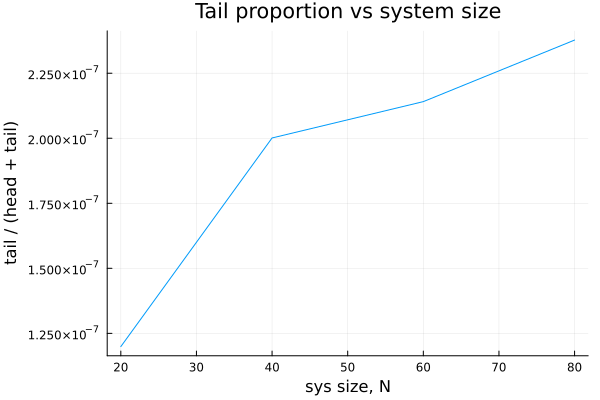

In [280]:
# try plotting these tail weights

p3 = plot(title="Tail weight with N")

ns = []
tails = []

for (n, idx) in sorted_pairs
    ss = N_to_SS_map[n]
    head, tail = calculate_sum_of_schmidt_coeffs_around_dev_idx(ss, idx)
    push!(ns, n)
    @info "N=$n, head + tail $(head + tail)"
    push!(tails, tail)
end

plot(ns, tails, title="Tail proportion vs system size", ylabel="tail / (head + tail)", xlabel="sys size, N", legend=false)

this roughly linear increase maybe suggests
- as we go to large system sizes, an approximation by cutting off the tail will probably be worse and worse
- in thermodynamic limit - everything is tail

there really isn't enough data to tell at the moment.

## Truncation

So we have this deviation index at 21. What if we try running a simulation with the same params, but a maxbonddim of 21?

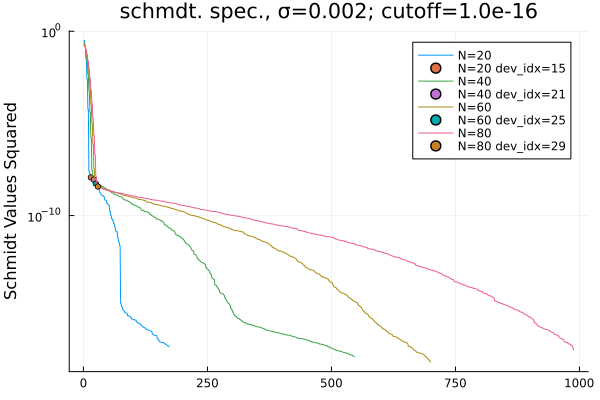

In [281]:
acc = system_params["ACC"]
p = plot(title="schmdt. spec., σ=$σ; cutoff=$acc", ylabel="Schmidt Values Squared", legend=:topright,
    yscale=:log,
    # xscale=:log
)

dev_idxs = Dict{Int, Int}()
for N in N_vals
    if !haskey(N_to_SS_map, N)
        continue
    end

    spec = N_to_SS_map[N]

    # want to find the deviation index using kneedle
    dev_idx = find_deviation_idx(spec)
    dev_idx_val = spec[dev_idx]

    dev_idxs[N] = dev_idx

    plot!(p, 1:length(spec), spec, label="N=$N")
    scatter!(p, [dev_idx], [dev_idx_val], markersize=3, label="N=$N dev_idx=$dev_idx")
end

display(p)
# savefig(p, joinpath(CURRENT_DIR, "schmidt_spectra_constant_disorder_σ=$(σ)_acc=$acc.png"))

this has been done, so we can load it  in

In [282]:
system_params = Dict{String,Any}(
                    "J" => -1.0,
                    "Δ" => -1.0,
                    "μ" => 1.0,
                    "NUM_SWEEPS" => 30,
                    "MAX_BOND_DIM" => 21,
                    "ACC" => 10^-16
                    )

run_params = Dict{String, Any}(
                    "N" => 40,
                    "σ" => 0.002
)

FP = extract_filename_from_system_params(system_params)
MPS_FP = path = joinpath(CURRENT_DIR, "../../data/storage/$(FP).hd5")
matches = find_runs_by_params(MPS_FP, run_params; load_psi=true, instance_selection=:latest)
if matches !== nothing @info "Found psi matching params..." end
psi_truncated = matches[1].psi
@info maxlinkdim(psi_truncated)

┌ Info: Found psi matching params...
└ @ Main /Users/jamesneville-rolfe/dev/uni/msciproject/programs/schmidt_spectra/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X20sZmlsZQ==.jl:18
┌ Info: 21
└ @ Main /Users/jamesneville-rolfe/dev/uni/msciproject/programs/schmidt_spectra/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X20sZmlsZQ==.jl:20


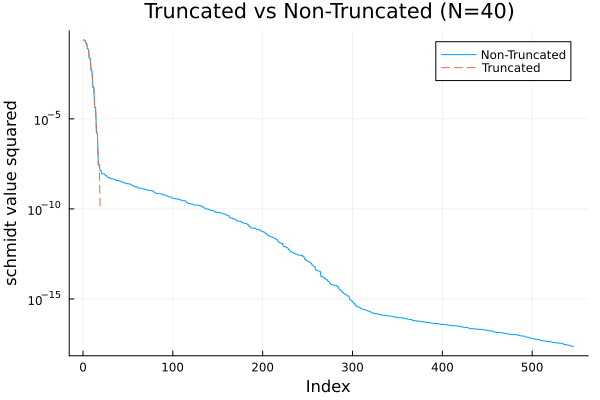

┌ Info: Created Schmdit spectrum.
└ @ Main /Users/jamesneville-rolfe/dev/uni/msciproject/programs/schmidt_spectra/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X21sZmlsZQ==.jl:4


"/Users/jamesneville-rolfe/dev/uni/msciproject/programs/schmidt_spectra/truncated_vs_non_truncated_N=40.png"

In [283]:
# now plot them both

schmidt_spec_truncated = get_squared_sorted_schmidt_spectrum_from_mps(matches[1].psi)
@info "Created Schmdit spectrum."

schmidt_spec_non_truncated = N_to_SS_map[40]
x = 1:length(schmidt_spec_non_truncated)

p2 = plot(title="Truncated vs Non-Truncated (N=40)", yscale=:log10, xlabel="Index", ylabel="schmidt value squared")

plot!(p2, 1:length(schmidt_spec_non_truncated), schmidt_spec_non_truncated, label="Non-Truncated")
plot!(p2, 1:length(schmidt_spec_truncated), schmidt_spec_truncated, label="Truncated", linestyle=:dash)

display(p2)
savefig(p2, joinpath(CURRENT_DIR, "truncated_vs_non_truncated_N=40.png"))

In [284]:
include("../../data/helpers/dmrg.jl")

function get_energy_from_mps(mps::MPS, A, N, J, Δ)
    sites = siteinds(mps)
    local H = create_xxz_hamiltonian_mpo(N, A, J, Δ, sites)
    energy = inner(mps', H, mps)
    return energy
end

   Resolving package versions...
     Project No packages added to or removed from `~/dev/uni/msciproject/Project.toml`
    Manifest No packages added to or removed from `~/dev/uni/msciproject/Manifest.toml`


get_energy_from_mps (generic function with 2 methods)

In [300]:
system_params = Dict{String,Any}(
                    "J" => -1.0,
                    "Δ" => -1.0,
                    "μ" => 1.0,
                    "NUM_SWEEPS" => 30,
                    "MAX_BOND_DIM" => 1000,
                    "ACC" => 10^-16
                    )

run_params = Dict{String, Any}(
                    "N" => 40,
                    "σ" => 0.002
)

FP = extract_filename_from_system_params(system_params)
MPS_FP = path = joinpath(CURRENT_DIR, "../../data/storage/$(FP).hd5")
matches = find_runs_by_params(MPS_FP, run_params; load_psi=true, instance_selection=:latest)
if matches !== nothing @info "Found psi matching params..." end
psi_non_truncated = matches[1].psi
@info maxlinkdim(psi_non_truncated)

┌ Info: Found psi matching params...
└ @ Main /Users/jamesneville-rolfe/dev/uni/msciproject/programs/schmidt_spectra/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X23sZmlsZQ==.jl:18
┌ Info: 555
└ @ Main /Users/jamesneville-rolfe/dev/uni/msciproject/programs/schmidt_spectra/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X23sZmlsZQ==.jl:20


In [286]:
A = generate_fully_connected_wam(40, 0.002, 1.0) # use same wam for both

non_trunc_energy = get_energy_from_mps(psi_non_truncated, A, 40, -1.0, -1.0)
trunc_energy = get_energy_from_mps(psi_truncated, A, 40, -1.0, -1.0)

-204.99424636647674

In [287]:
@info "Original energy: $non_trunc_energy"
@info "Truncated energy: $trunc_energy"

abs_error = abs(non_trunc_energy - trunc_energy)
rel_error = abs_error / abs(non_trunc_energy) # error rel to system scale
@info "Absolute error: $abs_error"
@info "Relative error: $rel_error"

┌ Info: Original energy: -204.99423153620484
└ @ Main /Users/jamesneville-rolfe/dev/uni/msciproject/programs/schmidt_spectra/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X24sZmlsZQ==.jl:1
┌ Info: Truncated energy: -204.99424636647674
└ @ Main /Users/jamesneville-rolfe/dev/uni/msciproject/programs/schmidt_spectra/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X24sZmlsZQ==.jl:2
┌ Info: Absolute error: 1.483027190829489e-5
└ @ Main /Users/jamesneville-rolfe/dev/uni/msciproject/programs/schmidt_spectra/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X24sZmlsZQ==.jl:6
┌ Info: Relative error: 7.234482549659286e-8
└ @ Main /Users/jamesneville-rolfe/dev/uni/msciproject/programs/schmidt_spectra/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X24sZmlsZQ==.jl:7


In [303]:
truncated = truncate(psi_non_truncated; maxdim=21)
normalize!(truncated)


@info 1 - inner(truncated, truncated)
@info 1 - inner(psi_non_truncated, psi_non_truncated)


A = generate_fully_connected_wam(40, 0.002, 1.0) # use same wam for both

non_trunc_energy = get_energy_from_mps(psi_non_truncated, A, 40, -1.0, -1.0)
trunc_energy = get_energy_from_mps(truncated, A, 40, -1.0, -1.0)

@info "Original energy: $non_trunc_energy"
@info "Truncated energy: $trunc_energy"

abs_error = abs(non_trunc_energy - trunc_energy)
rel_error = abs_error / abs(non_trunc_energy) # error rel to system scale
@info "Absolute error: $abs_error"
@info "Relative error: $rel_error"

┌ Info: -3.1086244689504383e-15
└ @ Main /Users/jamesneville-rolfe/dev/uni/msciproject/programs/schmidt_spectra/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X31sZmlsZQ==.jl:5
┌ Info: -1.9984014443252818e-15
└ @ Main /Users/jamesneville-rolfe/dev/uni/msciproject/programs/schmidt_spectra/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X31sZmlsZQ==.jl:6
┌ Info: Original energy: -205.00226262722794
└ @ Main /Users/jamesneville-rolfe/dev/uni/msciproject/programs/schmidt_spectra/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X31sZmlsZQ==.jl:14
┌ Info: Truncated energy: -205.00227485678408
└ @ Main /Users/jamesneville-rolfe/dev/uni/msciproject/programs/schmidt_spectra/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X31sZmlsZQ==.jl:15
┌ Info: Absolute error: 1.2229556148213305e-5
└ @ Main /Users/jamesneville-rolfe/dev/uni/msciproject/programs/schmidt_spectra/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X31sZmlsZQ==.jl:19
┌ Info: Relative error: 5.965571302230594e-8
└ @ Main /U